In [53]:
%pip install matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import chipwhisperer as cw # You only can use the basic ChipWhisperer functions demonstrated in this basic code
import numpy as np
import random
from tqdm.notebook import trange
import struct


# Also the ChipWhisperer provides better plotting functions (based on matplotlib), choose what you prefer
import matplotlib.pyplot as plt

# Initialize ChipWhisperer components
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()

# we got 724, so we set it to be a little higher than that(because it depends on the id) 
scope.adc.samples=1500

OSError: Unable to communicate with found ChipWhisperer. Check that 
another process isn't connected to it and that you have permission to communicate with it.

In [ ]:
%%bash
make PLATFORM=CWLITEARM SOURCE=c_code.c

: 

In [ ]:
hex = "output-CWLITEARM.hex"
cw.program_target(scope, cw.programmers.STM32FProgrammer , hex)

In [92]:
def execute_trace(command, input_string):
    # Clears any leftover data and arms the scope
    scope.arm()

    # Convert input to bytearray
    if isinstance(input_string, str):
        input_data = bytearray(input_string, 'utf-8')
    else:
        input_data = bytearray(input_string)
        
    # Send the command
    target.simpleserial_write(command, input_data)

    # Capture the trace
    ret = scope.capture()
    if ret:
        raise Exception("Failed to capture trace")

    # Get the trace data
    trace = scope.get_last_trace()
    
    # READ RAW BYTES (Remove the .decode('utf-8'))
    response = target.simpleserial_read('r', 1)
    
    return trace, response

In [93]:
def set_seed(seed_value, is_high_hw=False):
    """
    Sends a 32-bit seed to the target.
    
    Args:
        seed_value (int): The 32-bit seed (0 to 2^32 - 1).
        is_high_hw (bool): If True, sends to the high HW LFSR ('b').
                          If False, sends to the low HW LFSR ('a').
    """
    
    # Select the command based on the flag
    # 'a' for low_hw, 'b' for high_hw
    command = 'b' if is_high_hw else 'a'
    
    # Pack the integer into 4 bytes (Little Endian)
    # Then convert to bytearray which simpleserial expects
    raw_bytes = struct.pack('<I', seed_value)
    input_data = bytearray(raw_bytes)
    
    # Send the seed to the target
    target.simpleserial_write(command, input_data)
    
    # Read the ACK ('r' command) from the target
    # 0xAA for low, 0xBB for high (as defined in our C code)
    response = target.simpleserial_read('r', 1, timeout=100)
    
    return response

In [21]:
# --- Advanced Functional Verification ---
print("\nVerifying LFSR Logic with Interesting Seeds...")

# Test Case A: Seed where result LSB should be 0x01
seed_a = 0x00000003
print(f"Testing Seed: 0x{seed_a:08x}")
set_seed(seed_a, is_high_hw=False)
_, resp_a = execute_trace('c', "")
val_a = ord(resp_a[0]) if isinstance(resp_a, str) else resp_a[0]
print(f"Result LSB: 0x{val_a:02x} (Expected: 0x01)")

# Test Case B: Seed with High Bit
seed_b = 0x80000001
print(f"\nTesting Seed: 0x{seed_b:08x}")
set_seed(seed_b, is_high_hw=False)
_, resp_b = execute_trace('c', "")
val_b = ord(resp_b[0]) if isinstance(resp_b, str) else resp_b[0]
print(f"Result LSB: 0x{val_b:02x} (Expected: 0x00)")

# Check if both passed
if val_a == 0x01 and val_b == 0x00:
    print("\nPROVEN: LFSR Logic is 100% Correct and Active!")
else:
    print("\nLOGIC ERROR: Results do not match expected LFSR behavior.")


Verifying LFSR Logic with Interesting Seeds...
Testing Seed: 0x00000003


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a


Exception: Failed to capture trace

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import trange

def run_lfsr_ttest(is_high_hw=False, num_traces=5000, num_steps=1):
    """
    Performs a full Welch's T-Test experiment for a specific LFSR.
    
    Args:
        is_high_hw (bool): True for High HW (15) LFSR, False for Low HW (5).
        num_traces (int): Number of traces to collect.
        num_steps (int): Number of LFSR steps to perform per trace.
    """
    
    # 1. Configuration based on target LFSR
    # 'c' for Low HW step, 'd' for High HW step
    step_cmd = 'd' if is_high_hw else 'c'
    label = "High HW (15)" if is_high_hw else "Low HW (5)"
    fixed_seed = 0x12345678
    print(f"Fixed Seed: {fixed_seed:016x}")
    
    traces = []
    groups = []  # 0: Fixed, 1: Random
    
    print(f"--- Starting Leakage Assessment for {label} ({num_steps} steps) ---")
    
    # 2. Data Collection Loop (Fixed vs Random)
    for i in trange(num_traces, desc="Capturing"):
        # Flip a coin for the group
        is_random = np.random.randint(0, 2)
        
        if is_random:
            current_seed = np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32)
            groups.append(1)
        else:
            current_seed = fixed_seed
            groups.append(0)
            
        # Send seed to hardware
        set_seed(current_seed, is_high_hw=is_high_hw)
        
        # Trigger the operation and capture the power trace
        # Sending num_steps as a single-byte payload
        trace, _ = execute_trace(step_cmd, [num_steps])
        traces.append(trace)
        
    # Convert to Numpy arrays for analysis
    traces = np.array(traces)
    groups = np.array(groups)
    
    # 3. Statistical Analysis (Welch's T-Test)
    print("Calculating T-test statistics...")
    group_fixed = traces[groups == 0]
    group_random = traces[groups == 1]
    
    # Calculate T-values for every sample point (column)
    t_values = stats.ttest_ind(group_fixed, group_random, axis=0, equal_var=False)[0]
    
    # 4. Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(t_values, label=f'T-test ({label}, {num_steps} steps)', color='tab:blue', linewidth=1.5)
    
    # Significance Thresholds (+/- 4.5)
    plt.axhline(y=4.5, color='crimson', linestyle='--', label='Threshold ±4.5')
    plt.axhline(y=-4.5, color='crimson', linestyle='--')
    
    plt.title(f"Welch's T-Test: {label} (N={num_traces}, Steps={num_steps})")
    plt.xlabel("Sample Index")
    plt.ylabel("T-Statistic")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    y_abs_max = max(np.max(np.abs(t_values)), 6.0)
    plt.ylim(-y_abs_max, y_abs_max)
    
    plt.tight_layout()
    plt.show()
    
    # Summary Output
    max_t = np.max(np.abs(t_values))
    print(f"Experiment Finished. Max Absolute T-Value: {max_t:.4f}")
    if max_t > 4.5:
        print("RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)")
    else:
        print("RESULT: NO LEAKAGE DETECTED (t-value within 4.5 threshold)")

Fixed Seed: 0000000012345678
--- Starting Leakage Assessment for Low HW (5) (20 steps) ---


Capturing: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 42.53it/s]


Calculating T-test statistics...


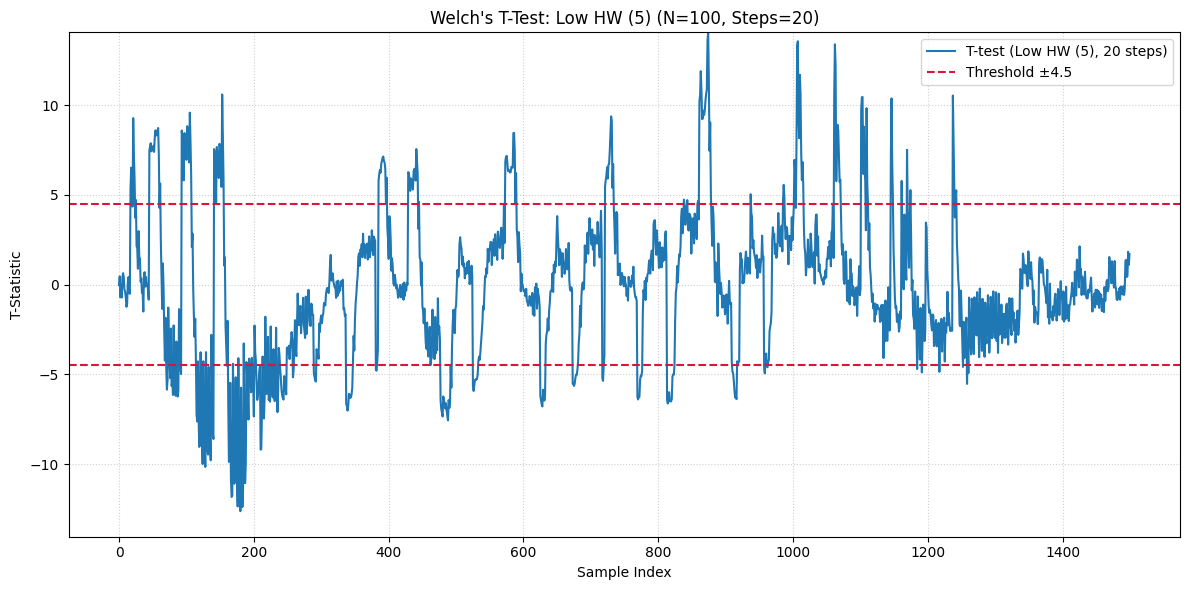

Experiment Finished. Max Absolute T-Value: 14.0493
RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)


In [97]:
# Executing T-test for Low Hamming Weight LFSR (Polynomial HW=5)
# Parameters: is_high_hw=False, num_traces=5000
run_lfsr_ttest(is_high_hw=False, num_traces=5000, num_steps=20)

Fixed Seed: 0000000012345678
--- Starting Leakage Assessment for High HW (15) (20 steps) ---


Capturing: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 42.60it/s]


Calculating T-test statistics...


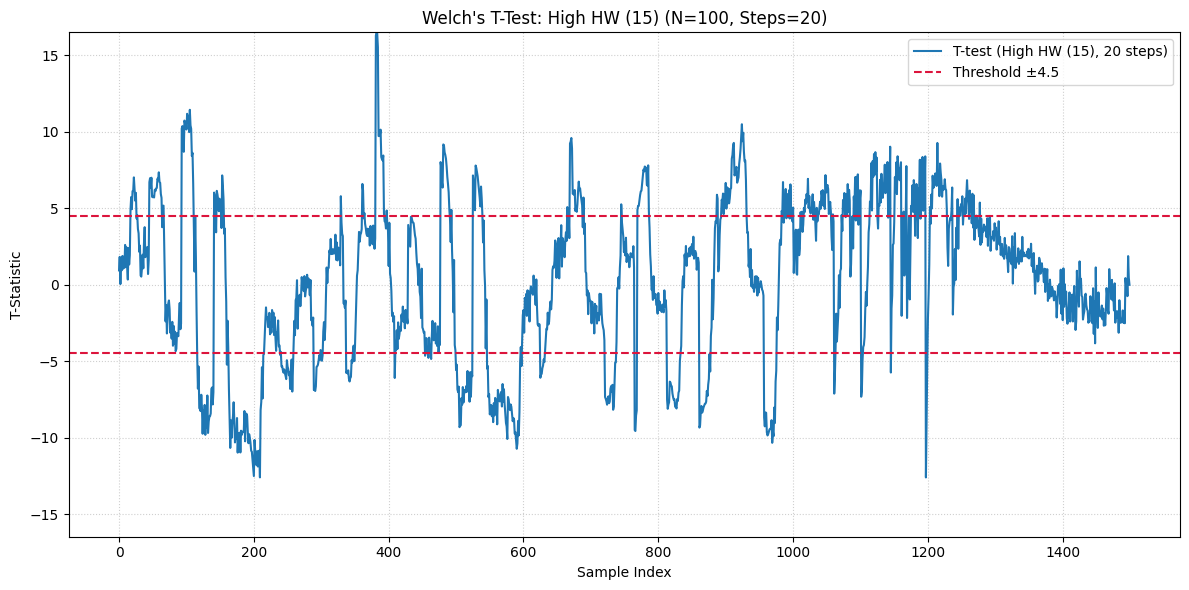

Experiment Finished. Max Absolute T-Value: 16.4824
RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)


In [98]:
# Executing T-test for High Hamming Weight LFSR (Polynomial HW=15)
# Parameters: is_high_hw=True, num_traces=5000
run_lfsr_ttest(is_high_hw=True, num_traces=5000, num_steps=20)

In [59]:
counts = []
for i in range(10):
    scope.arm()
    target.simpleserial_write('d', bytearray())
    scope.capture()
    counts.append(scope.adc.trig_count)

print(f"Trig counts: {counts}")
print(f"Min: {min(counts)}, Max: {max(counts)}")

Trig counts: [84, 84, 84, 84, 84, 84, 84, 84, 84, 84]
Min: 84, Max: 84


In [ ]:
# Disconnect ChipWhisperer components - very important to avoid simpleserial issues
scope.dis()
target.dis()